# CNN For MNIST Dataset

In [83]:
#Importing Libraries
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split



from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.utils import to_categorical


In [24]:
df=pd.read_csv('mnist_test.csv')
df_train = pd.read_csv('mnist_train.csv')

In [17]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
df.shape

(10000, 785)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


# Perceptron Model Training

# Splitting for models

In [25]:
X_train = df_train.drop('label',axis=1)
y_train = df_train['label']
X_test = df.drop('label',axis=1)
y_test = df['label']

In [26]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32') / 255.0

In [28]:
X_train

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
X_train_img = X_train.to_numpy().reshape(-1,28,28)
X_test_img = X_test.to_numpy().reshape(-1,28,28)

In [30]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [31]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [32]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

C:\Users\hp\miniconda3\envs\.env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
perceptron.compile(optimizer="sgd",loss='categorical_crossentropy',metrics=["accuracy"])

In [37]:
history_perc = perceptron.fit(X_train_img,y_train_cat, epochs=10,batch_size=32,validation_data=(X_test_img,y_test_cat), )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9029 - loss: 0.3483 - val_accuracy: 0.9104 - val_loss: 0.3258
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9057 - loss: 0.3393 - val_accuracy: 0.9120 - val_loss: 0.3202
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9075 - loss: 0.3321 - val_accuracy: 0.9133 - val_loss: 0.3144
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9090 - loss: 0.3262 - val_accuracy: 0.9140 - val_loss: 0.3092
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9105 - loss: 0.3214 - val_accuracy: 0.9159 - val_loss: 0.3057
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9120 - loss: 0.3171 - val_accuracy: 0.9160 - val_loss: 0.3021
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9132 - loss: 0.3135 - val_accuracy: 0.9172 - val_loss: 0.3005
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9138 - loss: 0.3103 - 

In [53]:
acc_per = perceptron.evaluate(X_test_img,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9227 - loss: 0.2762


In [41]:
acc_per

0.9168999791145325

# ANN Model

In [62]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(32,activation="relu"),
    Dense(10,activation='softmax')
])

In [63]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=["accuracy"])

In [67]:
history_ann = ann.fit(X_train_img,y_train_cat, epochs=10,batch_size=32,validation_data=(X_test_img,y_test_cat), )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9228 - loss: 0.2637 - val_accuracy: 0.9592 - val_loss: 0.1383
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9669 - loss: 0.1092 - val_accuracy: 0.9678 - val_loss: 0.1008
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9760 - loss: 0.0772 - val_accuracy: 0.9708 - val_loss: 0.0974
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9805 - loss: 0.0620 - val_accuracy: 0.9727 - val_loss: 0.0884
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9842 - loss: 0.0508 - val_accuracy: 0.9765 - val_loss: 0.0760
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9871 - loss: 0.0397 - val_accuracy: 0.9750 - val_loss: 0.0890
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9891 - loss: 0.0336 - val_accuracy: 0.9797 - val_loss: 0.0773
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9905 - loss: 0.0290 - 

In [68]:
acc_per = ann.evaluate(X_test_img,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9798 - loss: 0.0894


In [69]:
acc_per

0.9797999858856201

In [72]:
ann_pred = ann.predict(X_test_img)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [73]:
ann_pred

array([[4.42442055e-10, 3.40278312e-08, 2.57383294e-06, ...,
        9.99988437e-01, 3.83316774e-06, 4.71942940e-06],
       [1.99699039e-18, 4.14047047e-10, 1.00000000e+00, ...,
        5.09579968e-14, 3.14374243e-12, 2.01598784e-18],
       [1.42804909e-11, 9.99951482e-01, 1.03001857e-05, ...,
        1.94630479e-06, 3.26742847e-05, 4.14430339e-08],
       ...,
       [6.66052500e-14, 4.20306540e-10, 1.35145256e-10, ...,
        2.54639559e-07, 8.45195094e-11, 2.73891885e-07],
       [2.96074471e-12, 3.65365654e-11, 6.27382640e-13, ...,
        1.04101248e-10, 3.84989689e-05, 2.40053541e-08],
       [2.40492279e-11, 3.39366258e-13, 1.31287235e-14, ...,
        2.72854774e-14, 1.17172786e-12, 4.65560021e-11]],
      shape=(10000, 10), dtype=float32)

In [74]:
y_pred_ann_label = np.argmax(ann_pred,axis=1)
y_true_ann_label = np.argmax(y_test_cat,axis=1)

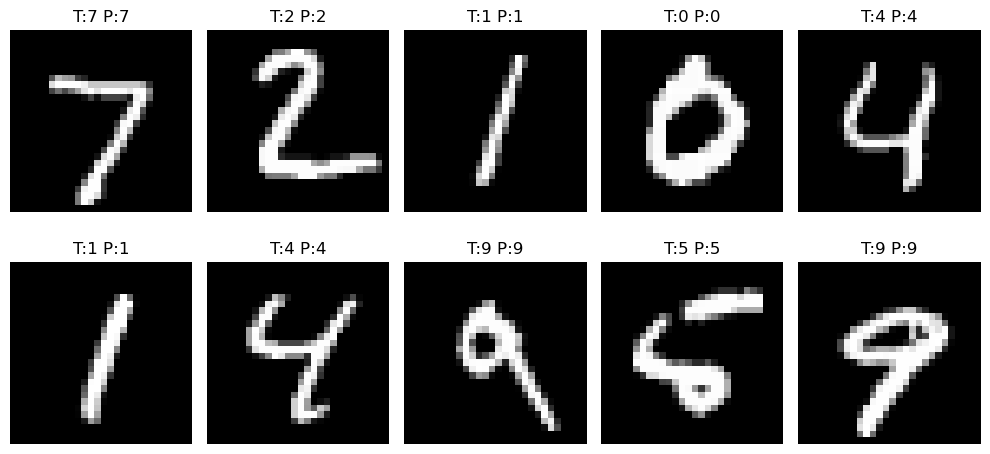

In [76]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test_img[i], cmap='gray')
    plt.title(f"T:{y_true_ann_label[i]} P:{y_pred_ann_label[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()    

# CNN Model

In [94]:
X_train_cnn = X_train.to_numpy().reshape(-1,28,28,1)
X_test_cnn = X_test.to_numpy().reshape(-1,28,28,1)

In [95]:
cnn = Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu',),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [96]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [97]:
history_cnn = cnn.fit(X_train_cnn,y_train_cat,epochs=10,batch_size=32,validation_data=(X_test_cnn,y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9383 - loss: 0.2000 - val_accuracy: 0.9848 - val_loss: 0.0452
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9778 - loss: 0.0749 - val_accuracy: 0.9867 - val_loss: 0.0365
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9836 - loss: 0.0558 - val_accuracy: 0.9906 - val_loss: 0.0273
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9865 - loss: 0.0440 - val_accuracy: 0.9922 - val_loss: 0.0244
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9888 - loss: 0.0370 - val_accuracy: 0.9905 - val_loss: 0.0282
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9897 - loss: 0.0319 - val_accuracy: 0.9914 - val_loss: 0.0247
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9915 - loss: 0.0274 - val_accuracy: 0.9931 - val_loss: 0.0213
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9926 - loss:

In [99]:
cnn_eval = cnn.evaluate(X_test_cnn,y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9940 - loss: 0.0250


In [100]:
cnn_pred = cnn.predict(X_test_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [101]:
y_pred_cnn_label = np.argmax(cnn_pred,axis=1)
y_pred_cnn_true = np.argmax(y_test_cat,axis=1)

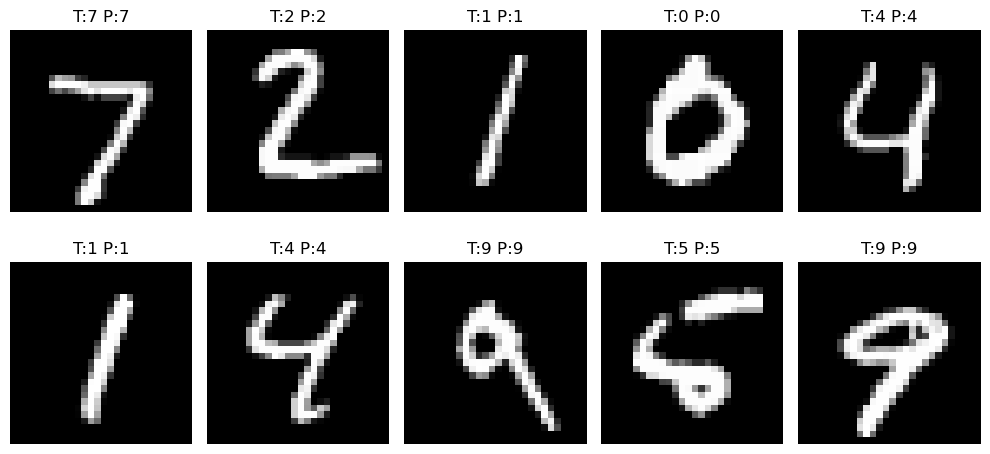

In [102]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test_cnn[i], cmap='gray')
    plt.title(f"T:{y_pred_cnn_true[i]} P:{y_pred_cnn_label[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()    